In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from torchvision import datasets, transforms
from torchvision.utils import make_grid



In [2]:
# Load and Prepare the Data
data = pd.read_csv('train.csv')
X = data.drop('label', axis=1).values
y = data['label'].values

# X , y is normal array, we need to convert it to tensor
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# normalize the features to [-1, 1]
X = X / 255.0 
X = (X - 0.5) / 0.5

#split the data into an 60% training set, 20% validation set and 20% test set 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Create Tensor Datasets and DataLoaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)




print(f'training set size: {len(train_dataset)}')
print(f'val set size: {len(val_dataset)}')
print(f'test set size: {len(test_dataset)}')

training set size: 25200
val set size: 8400
test set size: 8400


In [3]:
class Model(nn.Module):
    def __init__(self , in_features = 784 , hidden_layers = [128, 64] , out_feature = 10):
        super(). __init__()
        layers = []
        prev = in_features 
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        layers.append(nn.Linear(prev, out_feature))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = Model()

In [4]:

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
def Train_and_Evalute(lr=0.01, epochs=15, batch_size=64):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for i in range(epochs):
    

        model.train() 
        
        running_train_loss = 0.0
        correct_train, total_train = 0, 0
        
        for inputs, labels in train_loader:
            y_pred = model(inputs)
            loss = criterion(y_pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(y_pred.data, 1) 
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_accuracies.append(100 * correct_train / total_train)

        model.eval() 
            
        running_val_loss = 0.0
        correct_val, total_val = 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                y_pred = model(inputs)
                loss = criterion(y_pred, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(y_pred.data, 1) 
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(100 * correct_val / total_val)

    print(f'Final Train Loss: {train_losses[-1]:}, Final Train Accuracy: {train_accuracies[-1]:}%')
    print(f'Final Val Loss: {val_losses[-1]:}, Final Val Accuracy: {val_accuracies[-1]:}%')   
        
    return train_losses, val_losses, train_accuracies, val_accuracies


    


Final Train Loss: 0.21421729404535997, Final Train Accuracy: 93.71825396825396%
Final Val Loss: 0.2425508742418253, Final Val Accuracy: 93.20238095238095%


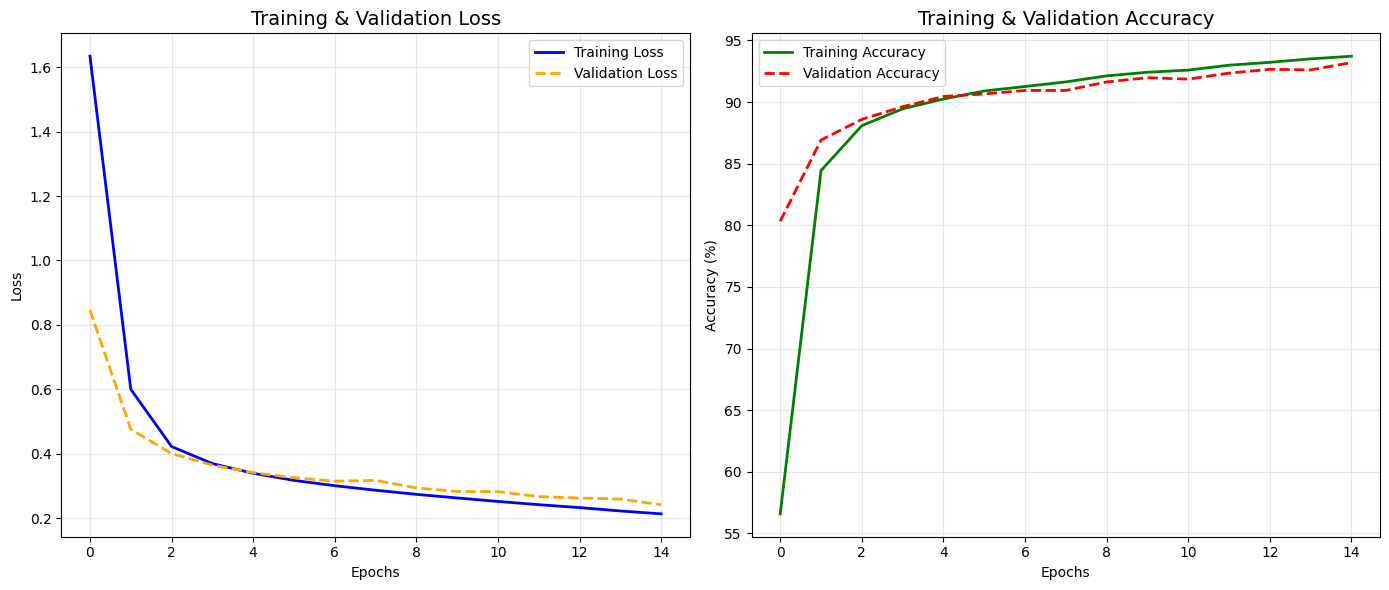

In [5]:
def PlotResults(train_losses, val_losses, train_accuracies, val_accuracies):
    # Create a figure with two subplots
    plt.figure(figsize=(14, 6))

    # Plot 1: Loss History
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
    plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--', lw=2)
    plt.title('Training & Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Accuracy History
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy', color='green', lw=2)
    plt.plot(val_accuracies, label='Validation Accuracy', color='red', linestyle='--', lw=2)
    plt.title('Training & Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

torch.manual_seed(42)
model = Model()
PlotResults(*Train_and_Evalute())





Learning Rate: 0.001
Final Train Loss: 0.5810150104730868, Final Train Accuracy: 85.10714285714286%
Final Val Loss: 0.5678270344029773, Final Val Accuracy: 85.29761904761905%


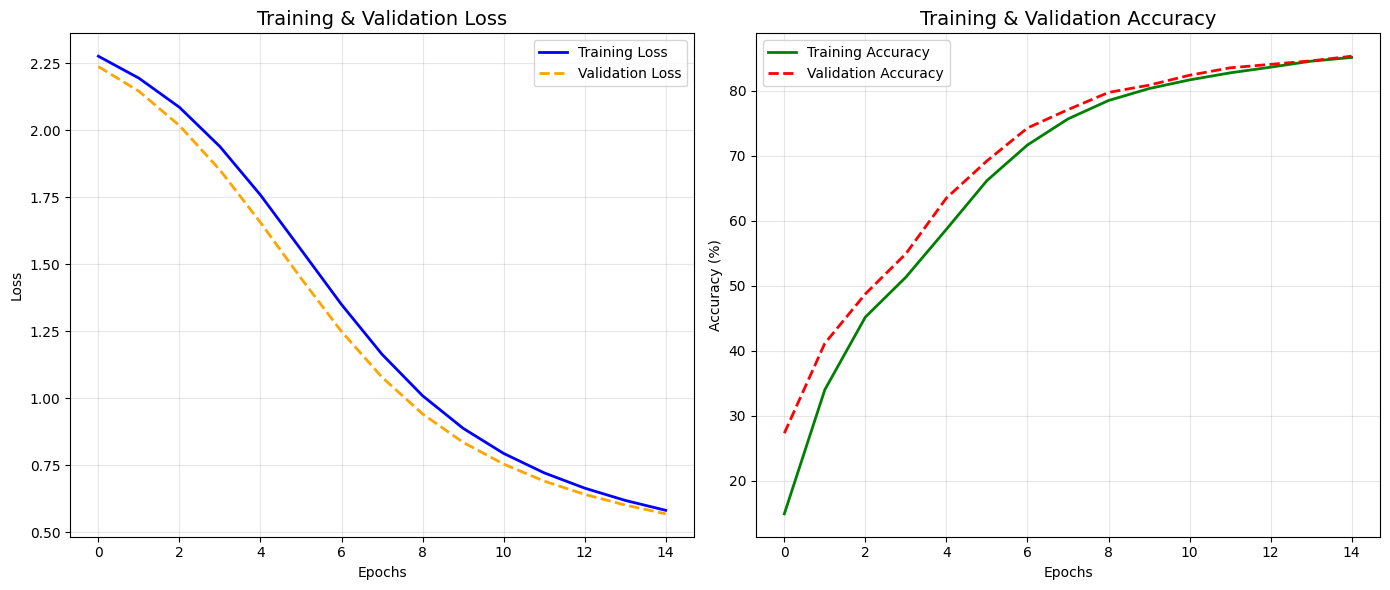

In [6]:
#Analysis
# Changing the learning rate, try 4 different learning rates at least.
# lr = [0.001 , 0.01 , 0.1 , 0.5]
# for lt = 0.001
torch.manual_seed(42)
model = Model()
print("Learning Rate: 0.001")
PlotResults(*Train_and_Evalute(lr=0.001))

Learning Rate: 0.1
Final Train Loss: 0.03226456652586892, Final Train Accuracy: 98.96825396825396%
Final Val Loss: 0.12831423158235283, Final Val Accuracy: 96.67857142857143%


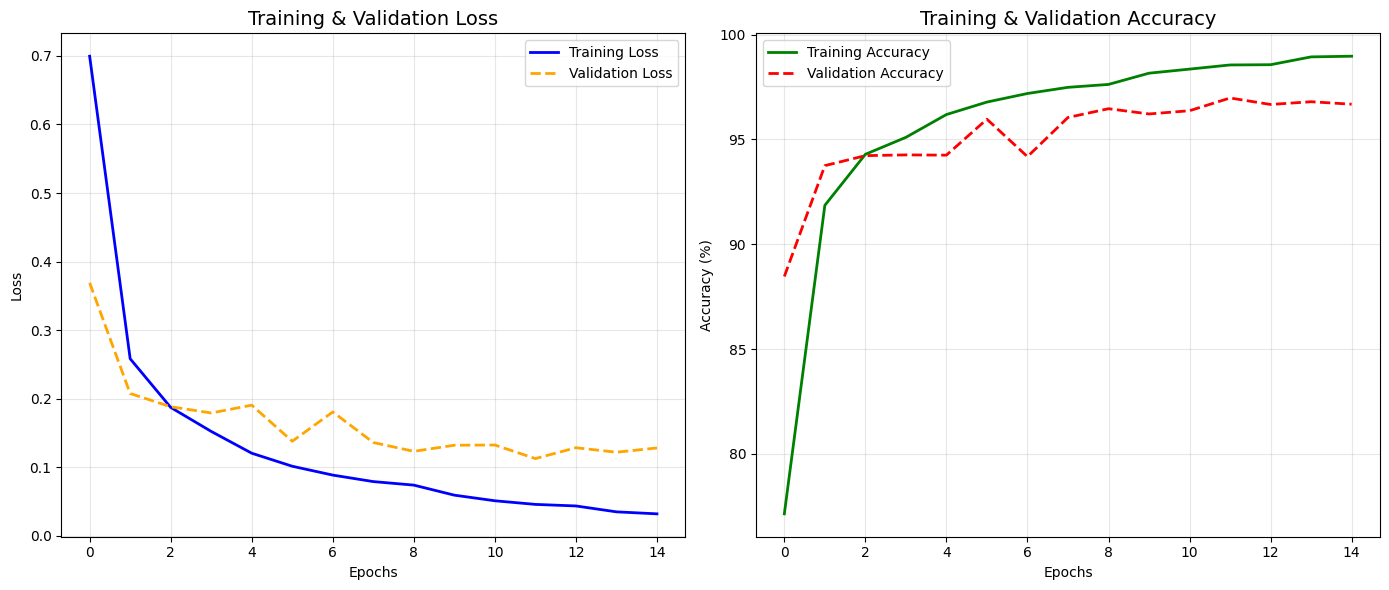

In [7]:
#Analysis
# Changing the learning rate, try 4 different learning rates at least.
# lr = [0.001 , 0.01 , 0.1 , 0.5]
# for lt = 0.1
torch.manual_seed(42)
model = Model()
print("Learning Rate: 0.1")
PlotResults(*Train_and_Evalute(lr=0.1))

Learning Rate: 0.5
Final Train Loss: 2.3035203763071053, Final Train Accuracy: 10.53968253968254%
Final Val Loss: 2.3017925891009243, Final Val Accuracy: 11.154761904761905%


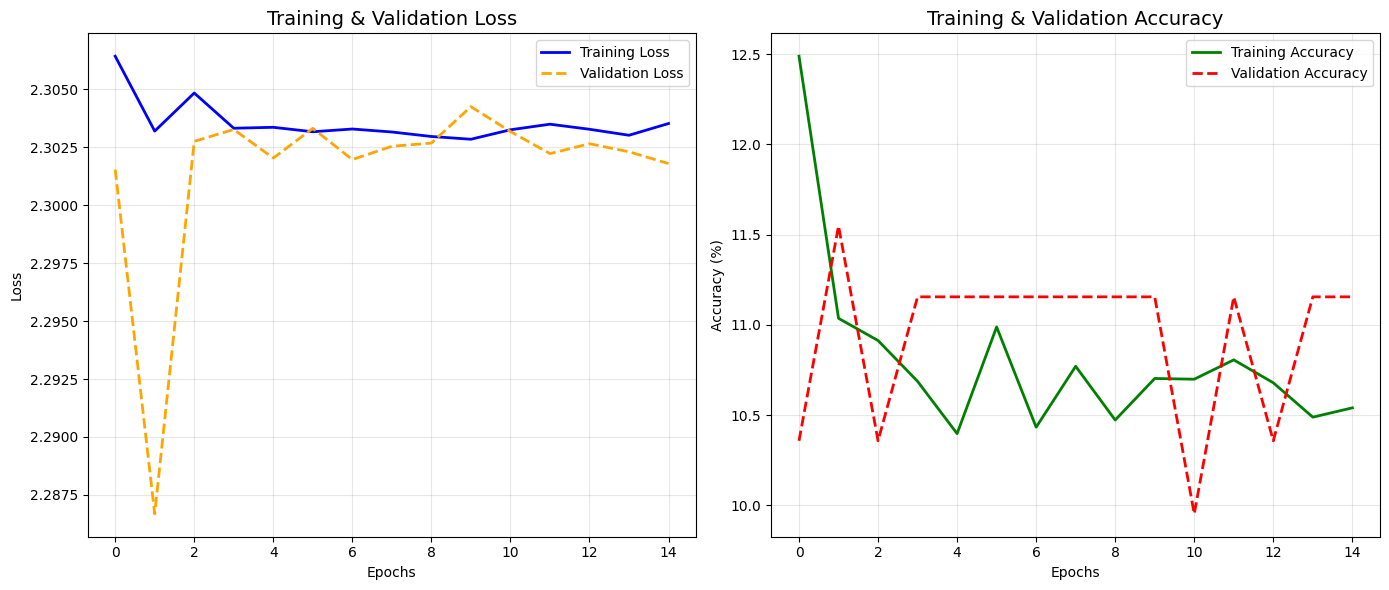

In [8]:
#Analysis
# Changing the learning rate, try 4 different learning rates at least.
# lr = [0.001 , 0.01 , 0.1 , 0.5]
# for lt = 0.5
torch.manual_seed(42)
model = Model()
print("Learning Rate: 0.5")
PlotResults(*Train_and_Evalute(lr=0.5))

Batch Size: 32
Final Train Loss: 0.12458697490294837, Final Train Accuracy: 96.45238095238095%
Final Val Loss: 0.16284299205931987, Final Val Accuracy: 95.45238095238095%


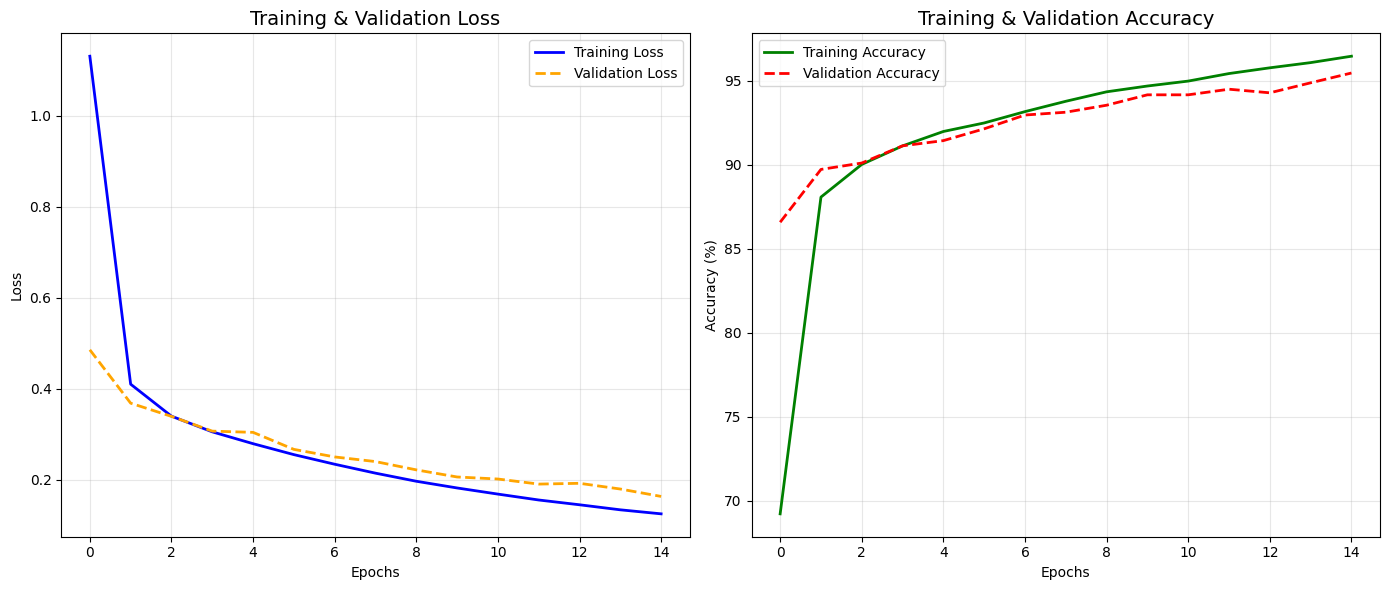

In [9]:
#Analysis
# Changing the batch size, try 4 different batch sizes at least.
# batch_size = [32, 64, 128, 256]
# for batch_size = 32
torch.manual_seed(42)
model = Model()
print("Batch Size: 32")
PlotResults(*Train_and_Evalute(batch_size=32))


Batch Size: 128
Final Train Loss: 0.2857782659948175, Final Train Accuracy: 91.82936507936508%
Final Val Loss: 0.3044067571560542, Final Val Accuracy: 91.26190476190476%


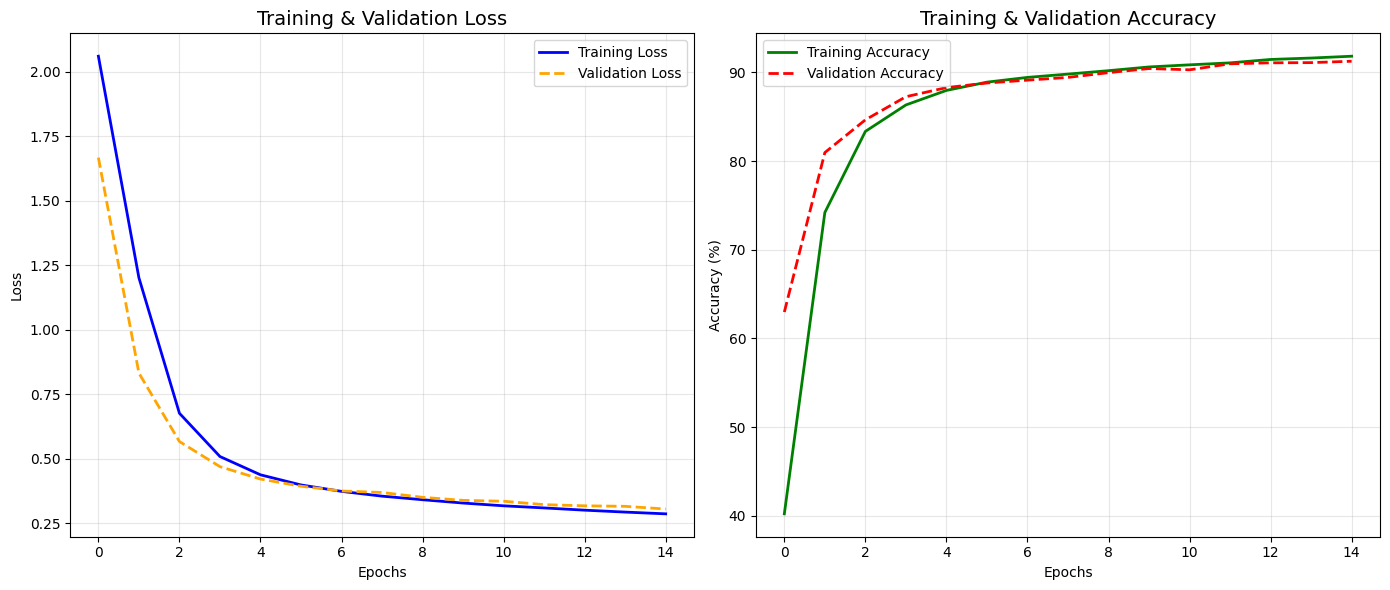

In [10]:
#Analysis
# Changing the batch size, try 4 different batch sizes at least.
# batch_size = [32, 64, 128, 256]
# for batch_size = 128
torch.manual_seed(42)
model = Model()
print("Batch Size: 128")
PlotResults(*Train_and_Evalute(batch_size=128))

Batch Size: 256
Final Train Loss: 0.3558358313760372, Final Train Accuracy: 89.94047619047619%
Final Val Loss: 0.36606347380262433, Final Val Accuracy: 89.60714285714286%


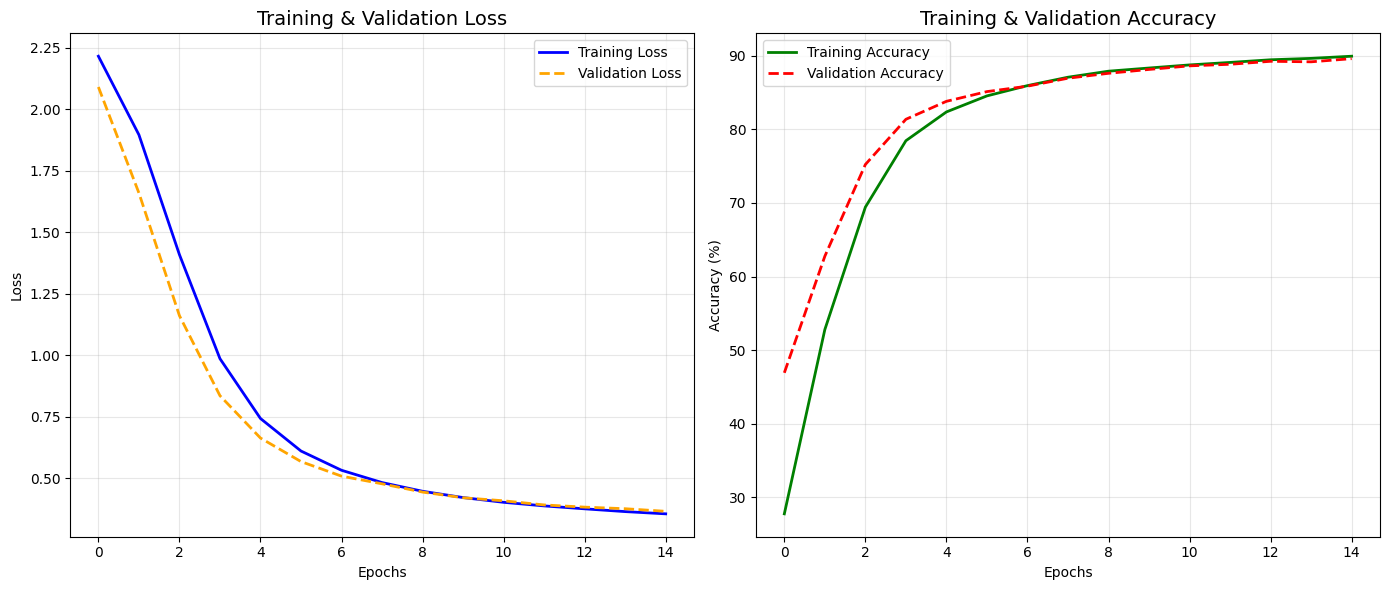

In [11]:
#Analysis
# Changing the batch size, try 4 different batch sizes at least.
# batch_size = [32, 64, 128, 256]
# for batch_size = 256
torch.manual_seed(42)
model = Model()
print("Batch Size: 256")
PlotResults(*Train_and_Evalute(batch_size=256))

Hidden Layers: [256, 128, 64]
Final Train Loss: 0.20512859956337715, Final Train Accuracy: 93.85317460317461%
Final Val Loss: 0.23354739340191538, Final Val Accuracy: 93.21428571428571%


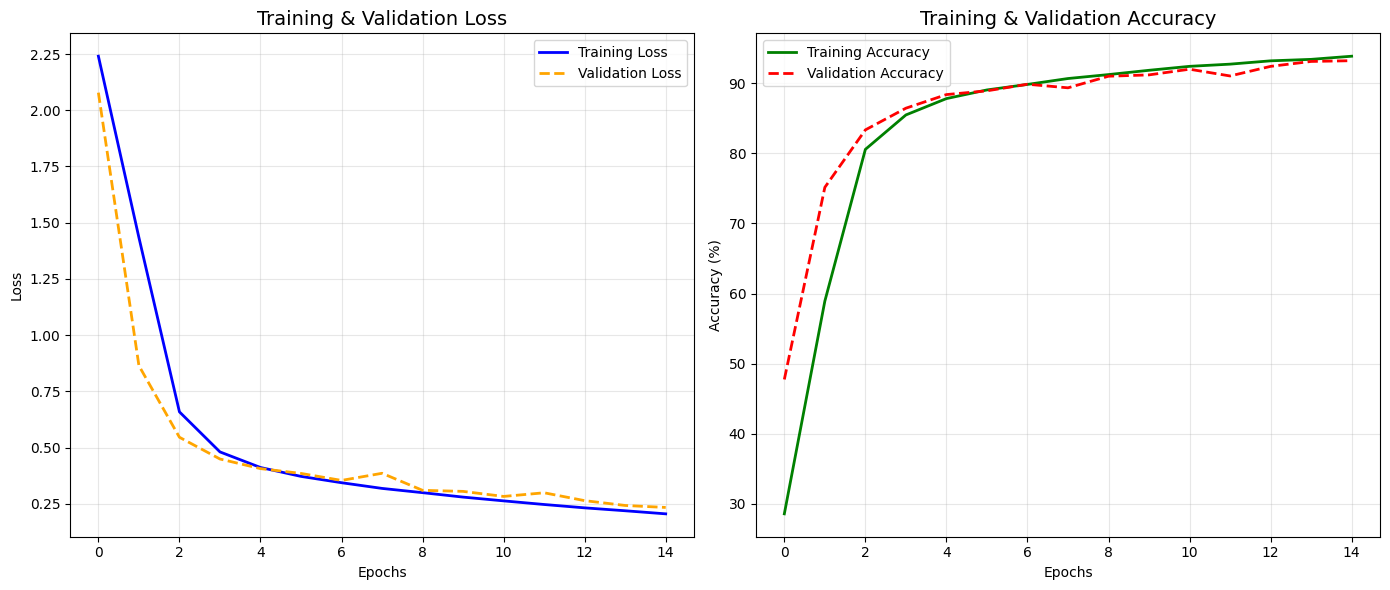

In [12]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 3 hidden layers with 256, 128, 64 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[256, 128, 64])
print("Hidden Layers: [256, 128, 64]")
PlotResults(*Train_and_Evalute())


Hidden Layers: [512, 256, 128, 64]
Final Train Loss: 0.1919117399259721, Final Train Accuracy: 94.11111111111111%
Final Val Loss: 0.24445801290373007, Final Val Accuracy: 93.10714285714286%


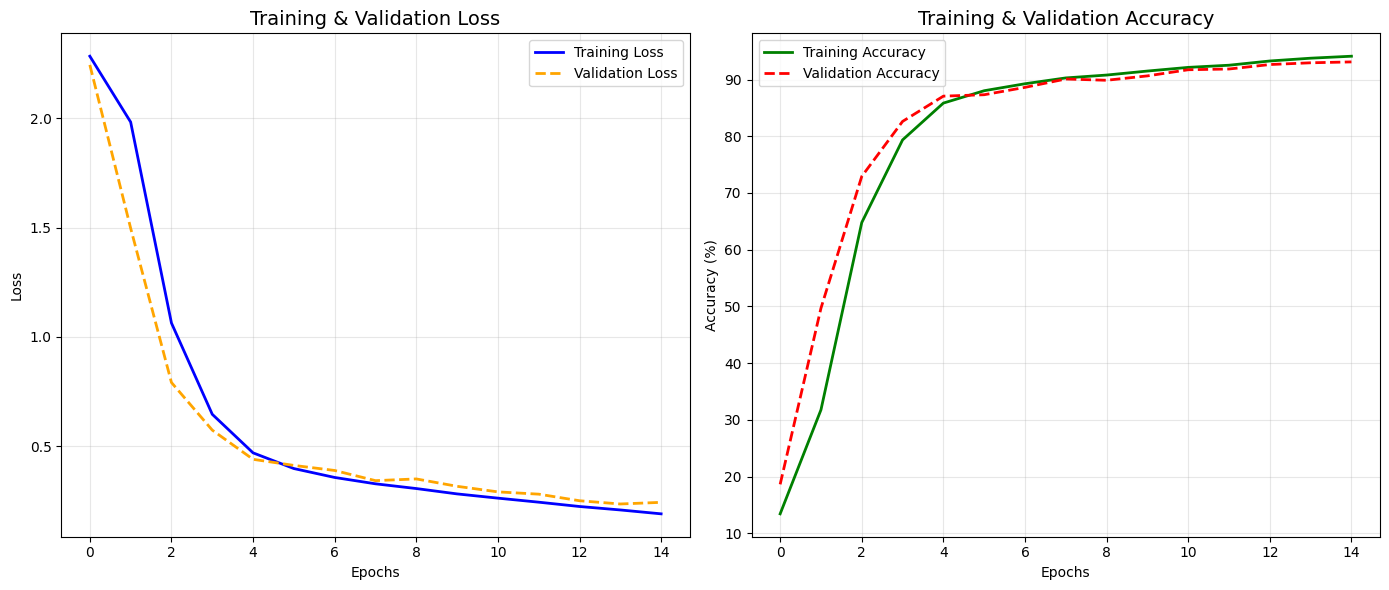

In [13]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 4 hidden layers with 512, 256, 128, 64 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[512, 256, 128, 64])
print("Hidden Layers: [512, 256, 128, 64]")
PlotResults(*Train_and_Evalute())

Hidden Layers: [512, 256, 128, 64, 32]
Final Train Loss: 0.1900194018114793, Final Train Accuracy: 94.6547619047619%
Final Val Loss: 0.22750406509095972, Final Val Accuracy: 93.92857142857143%


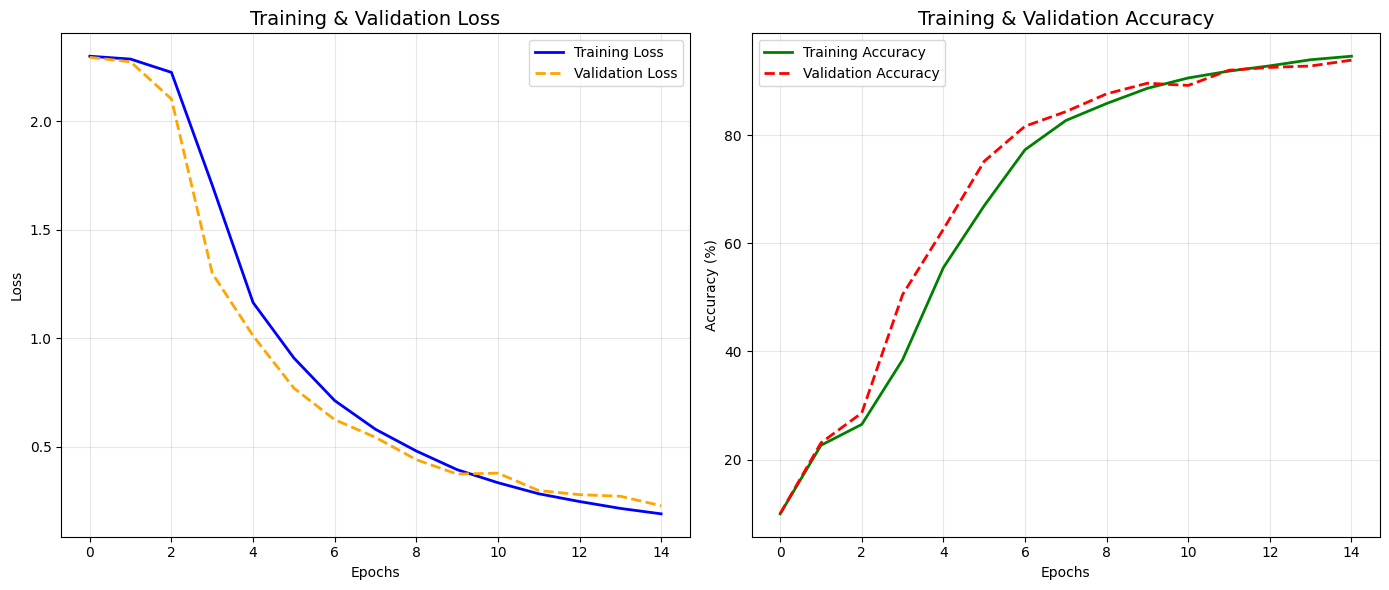

In [14]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 5 hidden layers with 512, 256, 128, 64, 32 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[512, 256, 128, 64, 32])
print("Hidden Layers: [512, 256, 128, 64, 32]")
PlotResults(*Train_and_Evalute())


Hidden Layers: [256, 128]
Final Train Loss: 0.207143040667028, Final Train Accuracy: 93.9484126984127%
Final Val Loss: 0.2406804904511029, Final Val Accuracy: 93.02380952380952%


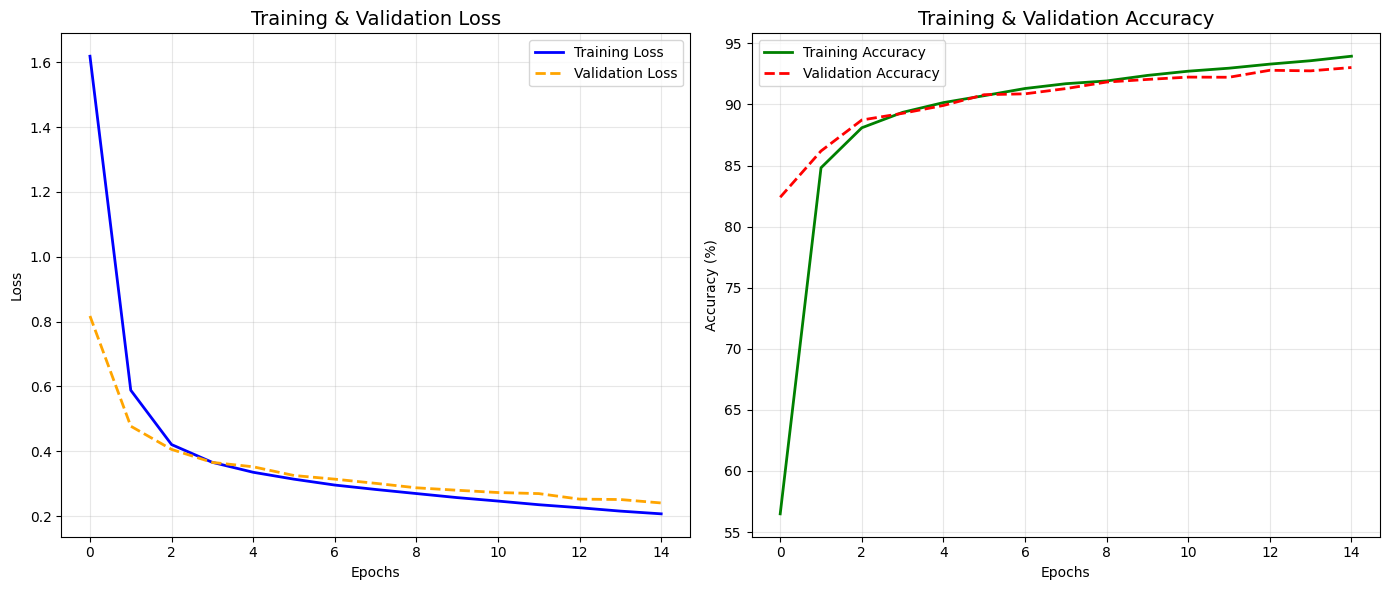

In [15]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 2 hidden layers with 256, 128 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[256, 128])
print("Hidden Layers: [256, 128]")
PlotResults(*Train_and_Evalute())

Hidden Layers: [512, 256]
Final Train Loss: 0.1955456964123219, Final Train Accuracy: 94.26984126984127%
Final Val Loss: 0.2288582573052157, Final Val Accuracy: 93.25%


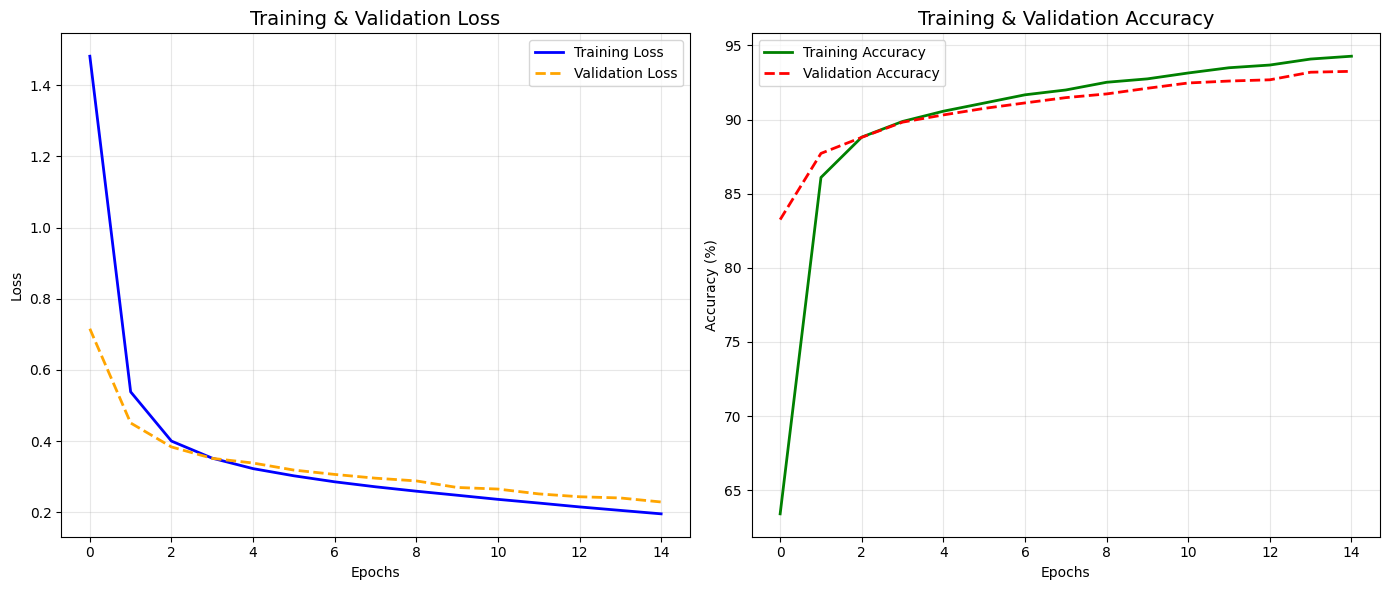

In [16]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 2 hidden layers with 512, 256 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[512, 256])
print("Hidden Layers: [512, 256]")
PlotResults(*Train_and_Evalute())

Hidden Layers: [32, 16]
Final Train Loss: 0.2535906017091371, Final Train Accuracy: 92.67460317460318%
Final Val Loss: 0.28922475109610596, Final Val Accuracy: 91.83333333333333%


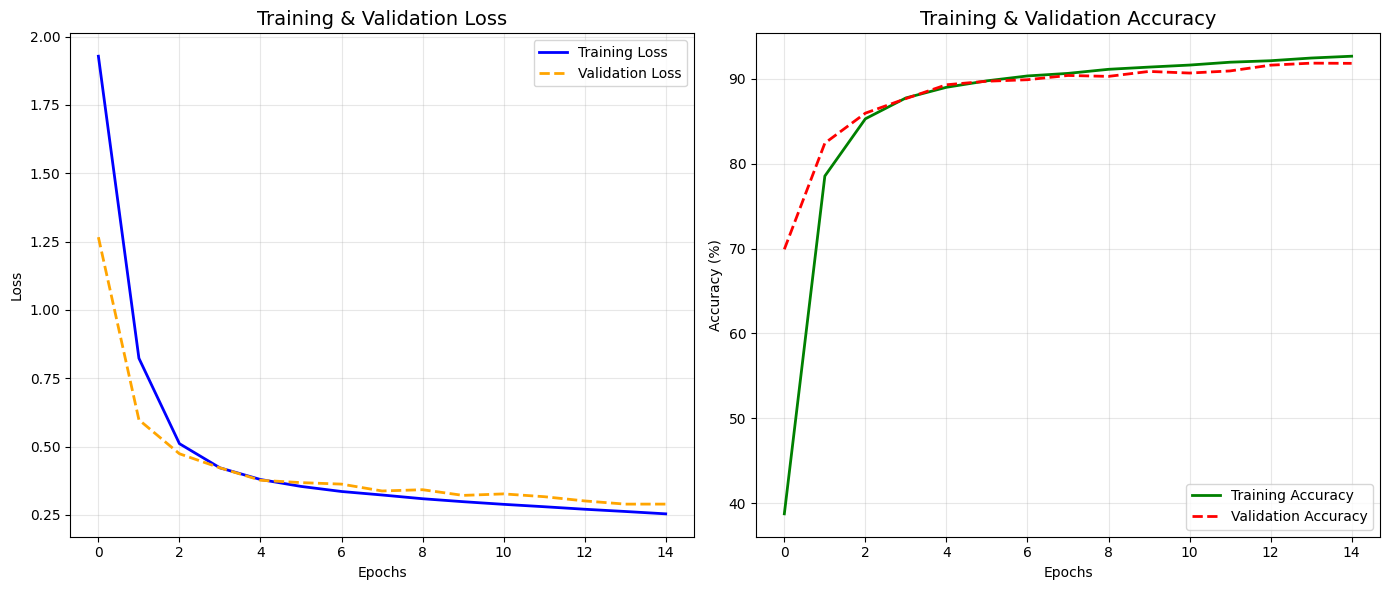

In [17]:
#Analysis
#Changing number of neurons and layers in your model. Try 4 different values for each.

# 2 hidden layers with 32, 16 neurons respectively
torch.manual_seed(42)
model = Model(hidden_layers=[32, 16])
print("Hidden Layers: [32, 16]")
PlotResults(*Train_and_Evalute())

Final Train Loss: 0.48899914783359777, Final Train Accuracy: 85.80555555555556%
Final Val Loss: 0.22737633820736047, Final Val Accuracy: 93.52380952380952%


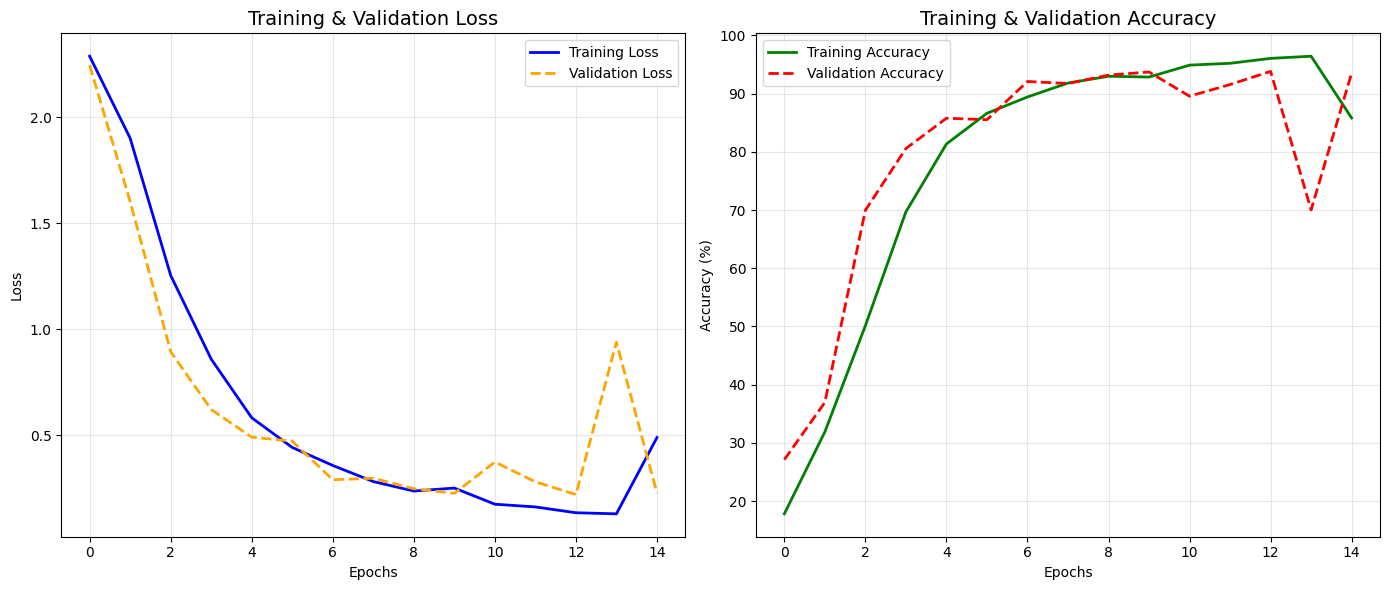

In [18]:
# the highest learning rate accuracy is 0.1
# the highest batch size accuracy is 256
# the highest hidden layers accuracy is [512, 256, 128, 64, 32]

torch.manual_seed(42)
model = Model(hidden_layers=[512, 256, 128, 64, 32])  
PlotResults(*Train_and_Evalute(lr=0.1, epochs=15, batch_size=256))

Final Train Loss: 0.1813110833335195, Final Train Accuracy: 94.7579365079365%
Final Val Loss: 0.1808935867791826, Final Val Accuracy: 95.08333333333333%


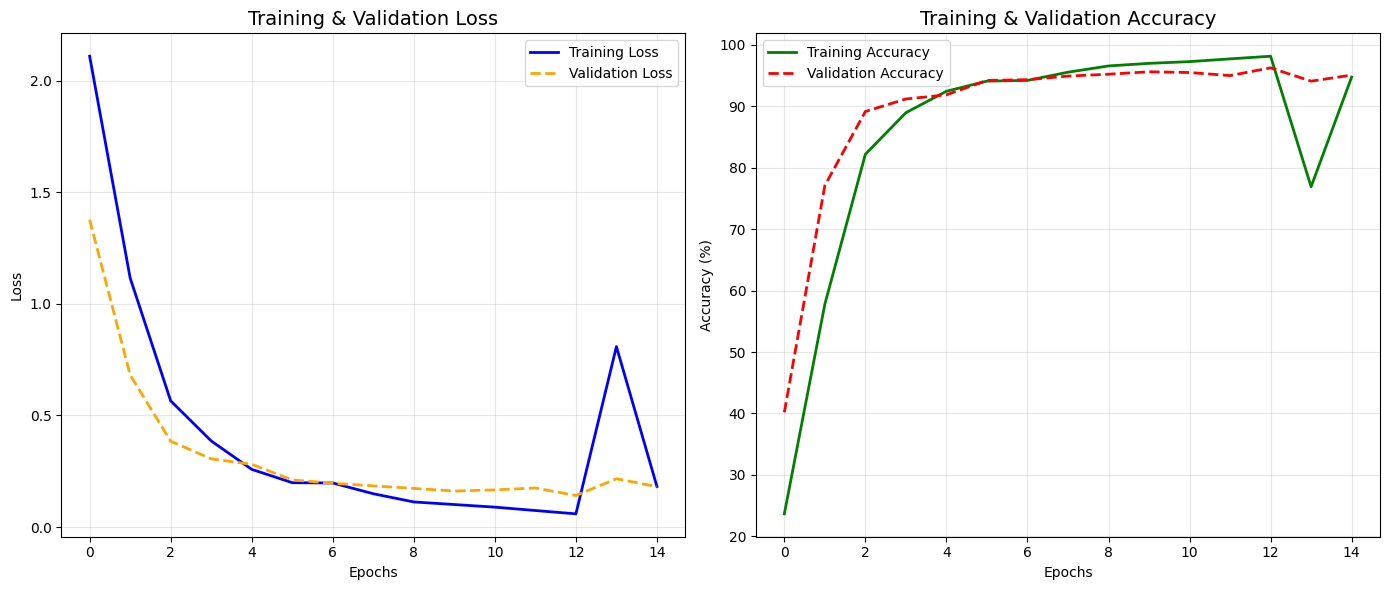

In [19]:

torch.manual_seed(42)
model = Model(hidden_layers=[512, 256, 128, 64, 32])  
PlotResults(*Train_and_Evalute(lr=0.1, epochs=15, batch_size=128))

In [20]:
# %%
def Test_Best_Model(model, test_loader):
    
    model.eval()
    
    criterion = nn.CrossEntropyLoss()
    running_test_loss = 0.0
    correct_test, total_test = 0, 0
    
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Forward pass
            y_pred = model(inputs)
            loss = criterion(y_pred, labels)
            
            
            running_test_loss += loss.item()
            _, predicted = torch.max(y_pred.data, 1) 
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    #Calculate final results
    test_loss = running_test_loss / len(test_loader)
    test_acc = 100 * correct_test / total_test
    
    print(f'Test Loss: {test_loss:}, Test Accuracy: {test_acc:}%')

    
    
    return test_acc




In [28]:
# Test the best model on the test set
torch.manual_seed(42)
model = Model(hidden_layers=[512, 256, 128, 64, 32])
Train_and_Evalute(lr=0.1, epochs=15, batch_size=32)
Test_Best_Model(model, test_loader)

Final Train Loss: 0.03628524363616149, Final Train Accuracy: 98.93253968253968%
Final Val Loss: 0.15046940653314, Final Val Accuracy: 96.14285714285714%
Test Loss: 0.12059625891869831, Test Accuracy: 96.72619047619048%


96.72619047619048

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def Plot_Confusion_Matrix(model, test_loader):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            _, predicted = torch.max(model(inputs), 1)
            all_preds.extend(predicted.numpy())
            all_true.extend(labels.numpy())

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title('Confusion Matrix', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()



Test Loss: 0.14925187137542348, Test Accuracy: 95.63095238095238%


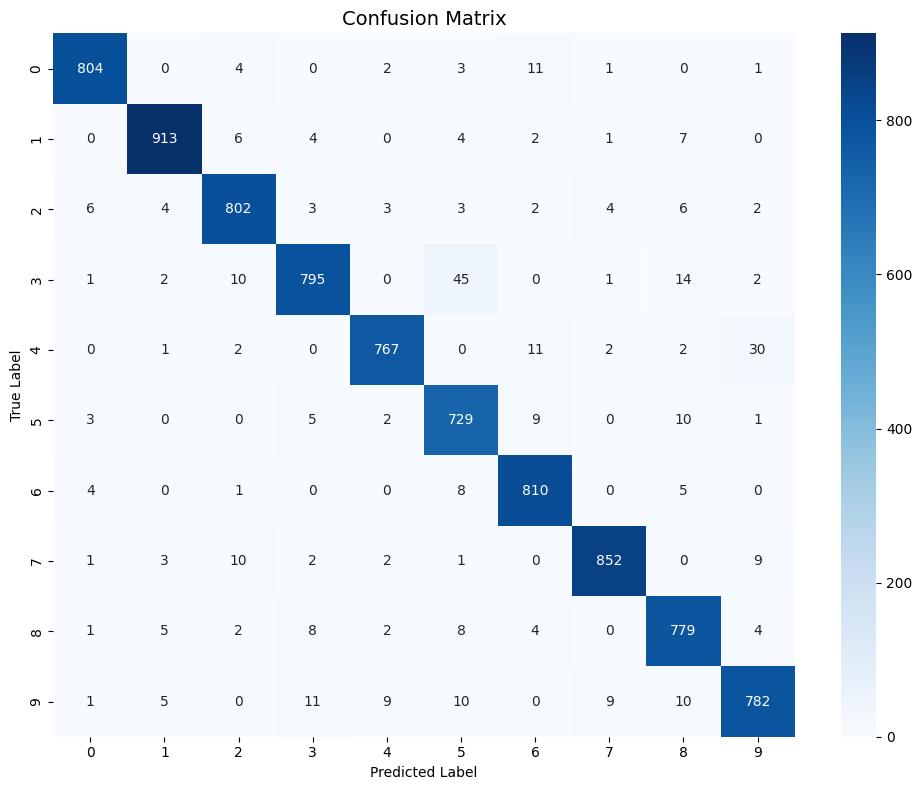

In [23]:
Test_Best_Model(model, test_loader)
Plot_Confusion_Matrix(model, test_loader)

### CNN


In [24]:


#model class
class CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, stride=1)
        self.ln1 = nn.LayerNorm([6, 26, 26])
        self.conv2 = nn.Conv2d(6, 16, kernel_size=3, stride=1)
        self.ln2 = nn.LayerNorm([16, 11, 11])


        self.dropout = nn.Dropout(0.3)


        # Fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)  
        x = self.conv1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2, 2)

        x = self.conv2(x)
        x = self.ln2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2, 2)

        x = x.view(-1, 16 * 5 * 5)  # Flatten

        x = self.dropout(x)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Final Train Loss: 0.03727273069074294, Final Train Accuracy: 98.83730158730158%
Final Val Loss: 0.053665832057104575, Final Val Accuracy: 98.53571428571429%


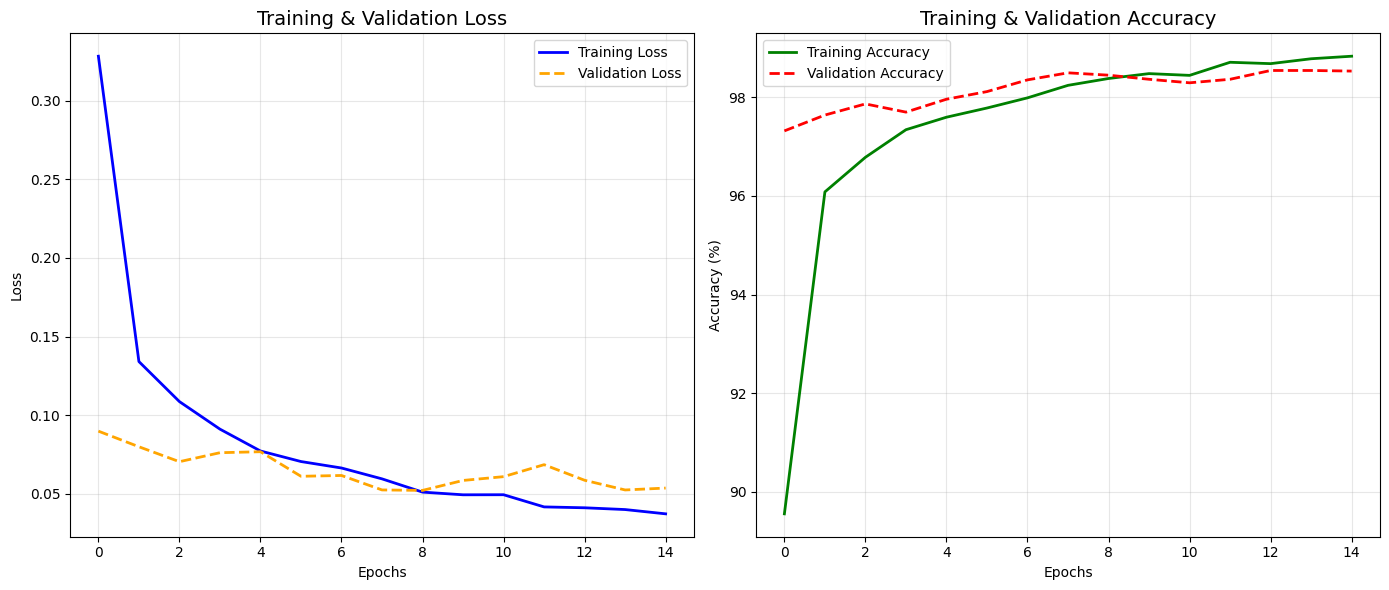

Test Loss: 0.05458992841307587, Test Accuracy: 98.63095238095238%


98.63095238095238

In [25]:
#Create CNN model instance
torch.manual_seed(42)
model = CNN_Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
PlotResults(*Train_and_Evalute(lr=0.1, epochs=15, batch_size=10))
Test_Best_Model(model, test_loader)


Final Train Loss: 0.03163063534760849, Final Train Accuracy: 99.01587301587301%
Final Val Loss: 0.05537073701384543, Final Val Accuracy: 98.54761904761905%


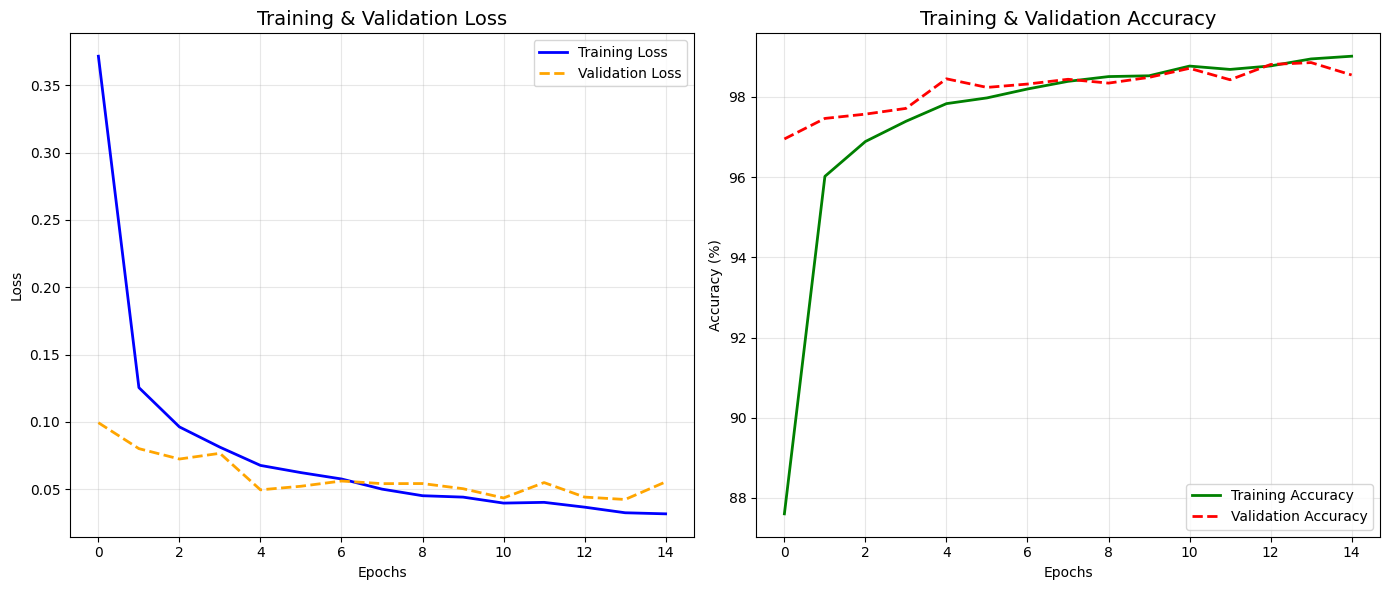

Test Loss: 0.04542846249056642, Test Accuracy: 98.63095238095238%


98.63095238095238

In [26]:
#Create CNN model instance
torch.manual_seed(42)
model = CNN_Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
PlotResults(*Train_and_Evalute(lr=0.1, epochs=15, batch_size=30))
Test_Best_Model(model, test_loader)


Final Train Loss: 0.20498392089168624, Final Train Accuracy: 93.88888888888889%
Final Val Loss: 0.15732880199656768, Final Val Accuracy: 95.44047619047619%


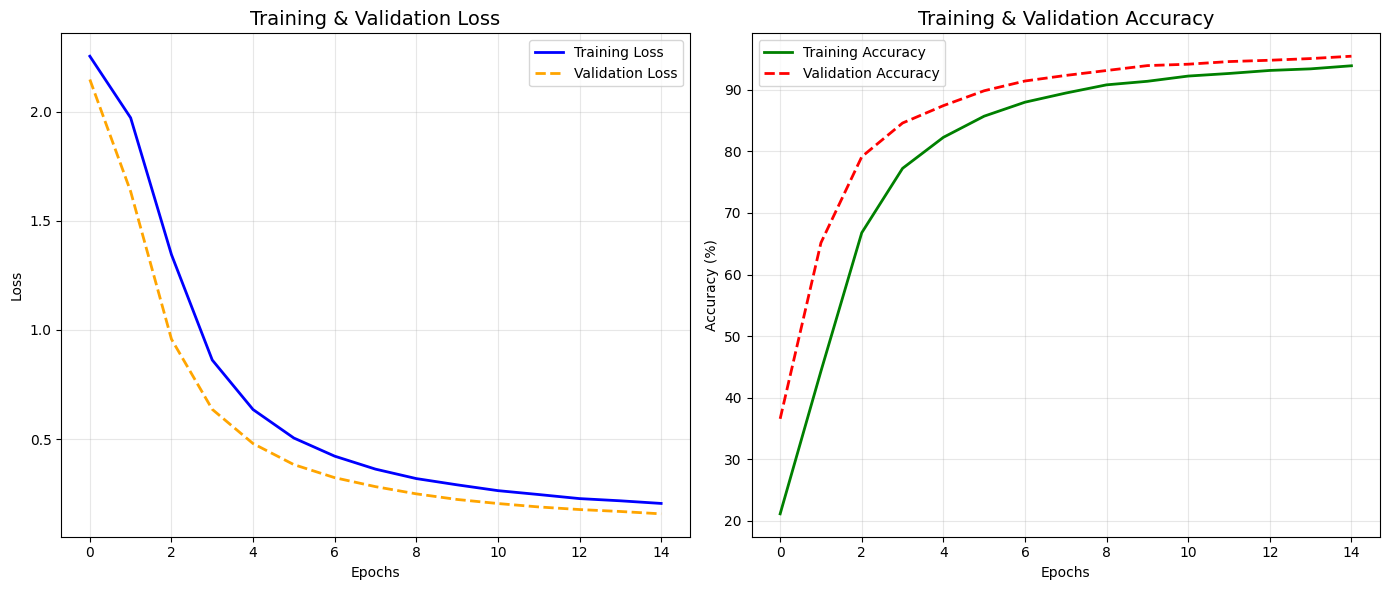

Test Loss: 0.14732705138510827, Test Accuracy: 95.91666666666667%


95.91666666666667

In [27]:
#Create CNN model instance
torch.manual_seed(42)
model = CNN_Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
PlotResults(*Train_and_Evalute(lr=0.01, epochs=15, batch_size=250))
Test_Best_Model(model, test_loader)
